# Dataset Exploration & Preprocessing Analysis
## Heritage Damage Multi-Task Deep Learning Pipeline

This notebook provides a comprehensive exploration of all six datasets used across the three sub-tasks of the pipeline.
It covers class distributions, bounding-box statistics, segmentation mask analysis, image statistics, and the
learned feature space visualised via t-SNE.

**Tasks covered:**
- **Classification** — binary crack/intact labelling (StructDamage, Historical Crack)
- **Detection** — multi-class defect localisation (DACL10K, Heritage Defect)
- **Segmentation** — pixel-level crack delineation (CrackForest, Masonry)

All output figures are saved to `../outputs/eda/`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Patch
from PIL import Image
import os, csv, glob, random
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

BASE    = Path('../data')
OUT_EDA = Path('../outputs/eda')
OUT_EDA.mkdir(parents=True, exist_ok=True)
random.seed(42)
np.random.seed(42)

DETECT_CLASSES = ['Crack', 'Efflorescence', 'Spalling', 'Weathering', 'Wetspot']
DETECT_COLORS  = ['#e74c3c', '#3498db', '#f39c12', '#9b59b6', '#1abc9c']
print('Environment ready.')

Environment ready.


---
## 1. Dataset Landscape

The pipeline aggregates **six open-source datasets** (27,274 images total) to cover the full spectrum
of heritage damage assessment — from coarse image-level classification to fine-grained pixel-level crack mapping.

| Task | Dataset | Annotation Type | Source |
|------|---------|-----------------|--------|
| Classification | StructDamage | Image label (cracked / intact) | Kaggle |
| Classification | Historical Crack | Image label (cracked / intact) | Custom scrape |
| Detection | DACL10K | Bounding boxes — 5 classes | dacl.ai |
| Detection | Heritage Defect | Bounding boxes — 1 class | Custom |
| Segmentation | CrackForest | Binary pixel masks | TU Delft |
| Segmentation | Masonry | Binary pixel masks | Public |
| Segmentation | OmniCrack30K | Binary pixel masks | omnicrack30k.org |

Each task uses a different output representation and loss function, yet all share the same backbone
family (EfficientNet / YOLOv8) to leverage transfer learning from large-scale visual pre-training.

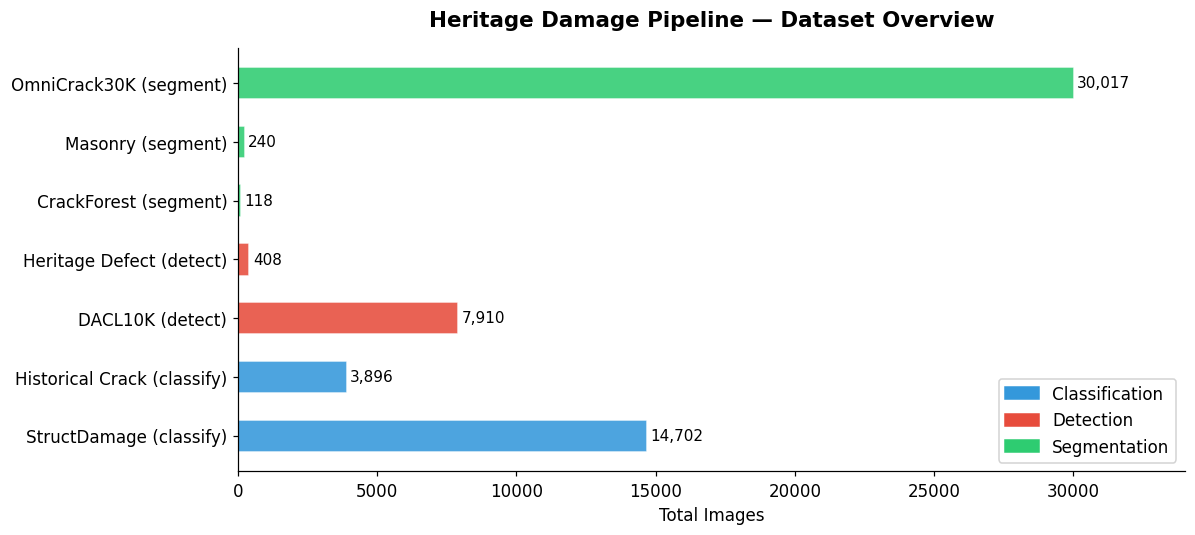

Total images across all datasets: 57,291


In [2]:
dataset_names  = [
    'StructDamage (classify)',
    'Historical Crack (classify)',
    'DACL10K (detect)',
    'Heritage Defect (detect)',
    'CrackForest (segment)',
    'Masonry (segment)',
    'OmniCrack30K (segment)',
]
dataset_totals = [14702, 3896, 7910, 408, 118, 240, 30017]
dataset_tasks  = ['cls', 'cls', 'det', 'det', 'seg', 'seg', 'seg']
task_palette   = {'cls': '#3498db', 'det': '#e74c3c', 'seg': '#2ecc71'}
bar_colors     = [task_palette[t] for t in dataset_tasks]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(dataset_names, dataset_totals, color=bar_colors,
               edgecolor='white', height=0.55, alpha=0.88)
for bar, val in zip(bars, dataset_totals):
    ax.text(bar.get_width() + 120, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=10)

legend_handles = [
    Patch(color='#3498db', label='Classification'),
    Patch(color='#e74c3c', label='Detection'),
    Patch(color='#2ecc71', label='Segmentation'),
]
ax.legend(handles=legend_handles, loc='lower right', framealpha=0.85)
ax.set_xlabel('Total Images')
ax.set_xlim(0, 34000)
ax.set_title('Heritage Damage Pipeline — Dataset Overview',
             fontsize=14, fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig(OUT_EDA / '01_dataset_overview.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Total images across all datasets: {sum(dataset_totals):,}')

---
## 2. Classification Data

Binary classification separates **cracked** from **intact** surfaces at image level.
The model (EfficientNet-B4) is optimised with **Binary Cross-Entropy** loss:

$$
\mathcal{L}_{\text{BCE}} = -\frac{1}{N}\sum_{i=1}^{N}\bigl[y_i\log\hat{y}_i + (1-y_i)\log(1-\hat{y}_i)\bigr]
$$

where $y_i \in \{0, 1\}$ is the ground-truth label and $\hat{y}_i = \sigma(f_\theta(x_i))$ is the sigmoid-activated output.

**StructDamage** is perfectly balanced across all splits (50 / 50).  
**Historical Crack** — used as a domain-transfer test set — has a pronounced imbalance:

$$
r = \frac{N_{\text{cracked}}}{N_{\text{intact}}} = \frac{757}{3139} \approx 0.24
$$

This 1:4 ratio motivates **weighted random sampling** to prevent the classifier from predicting
the majority class by default when evaluated on heritage imagery.

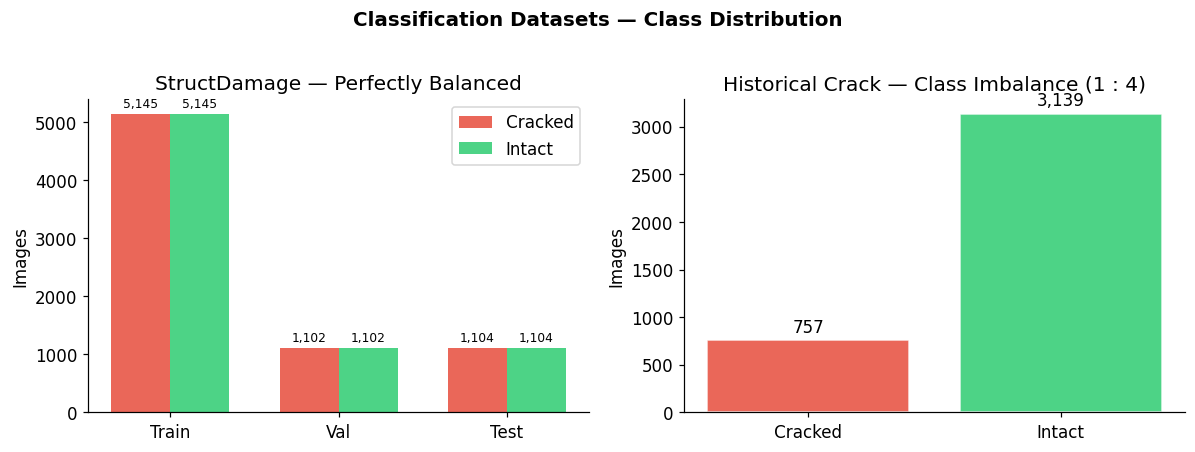

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# StructDamage
splits  = ['Train', 'Val', 'Test']
cracked = [5145, 1102, 1104]
intact  = [5145, 1102, 1104]
x = np.arange(len(splits))
w = 0.35
b1 = axes[0].bar(x - w/2, cracked, w, label='Cracked', color='#e74c3c', alpha=0.85)
b2 = axes[0].bar(x + w/2, intact,  w, label='Intact',  color='#2ecc71', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(splits)
axes[0].set_ylabel('Images')
axes[0].set_title('StructDamage — Perfectly Balanced')
axes[0].legend()
for bar in list(b1) + list(b2):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 60,
                 f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)

# Historical Crack
hc_vals   = [757, 3139]
hc_labels = ['Cracked', 'Intact']
hc_colors = ['#e74c3c', '#2ecc71']
b3 = axes[1].bar(hc_labels, hc_vals, color=hc_colors, alpha=0.85, edgecolor='white')
axes[1].set_ylabel('Images')
axes[1].set_title('Historical Crack — Class Imbalance (1 : 4)')
for bar, val in zip(b3, hc_vals):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 40,
                 f'{val:,}', ha='center', va='bottom', fontsize=11)

plt.suptitle('Classification Datasets — Class Distribution',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT_EDA / '02_class_balance.png', bbox_inches='tight', dpi=150)
plt.show()

### Sample Images — StructDamage

All images are resized to **224 × 224** pixels and normalised using ImageNet statistics:

$$
\hat{x}_c = \frac{x_c - \mu_c}{\sigma_c}, \qquad
\boldsymbol{\mu} = (0.485,\ 0.456,\ 0.406), \quad
\boldsymbol{\sigma} = (0.229,\ 0.224,\ 0.225)
$$

Visually, cracked surfaces show irregular texture discontinuities, while intact surfaces are smoother and more homogeneous.

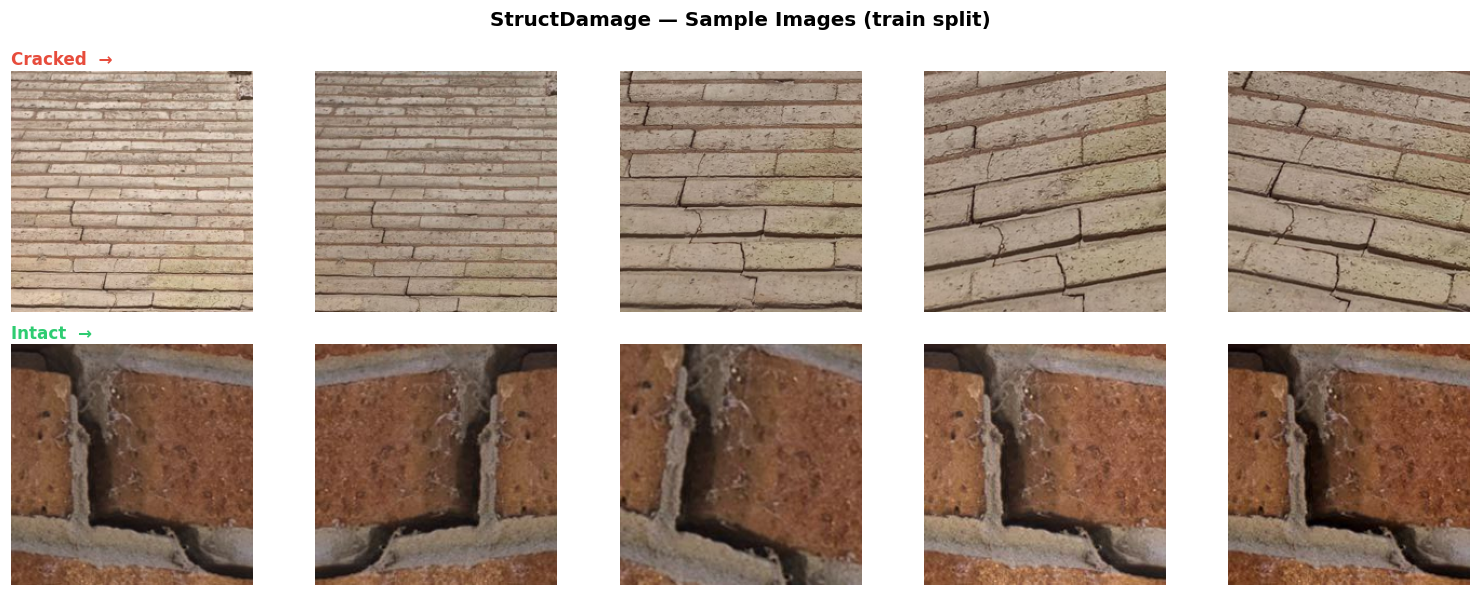

In [4]:
cracked_paths = sorted(glob.glob('../data/structdamage_classifier/train/cracked/*.jpg'))[:5]
intact_paths  = sorted(glob.glob('../data/structdamage_classifier/train/intact/*.jpg'))[:5]

fig, axes = plt.subplots(2, 5, figsize=(14, 5.5))

for col, path in enumerate(cracked_paths):
    img = Image.open(path).convert('RGB').resize((224, 224))
    axes[0, col].imshow(img)
    axes[0, col].axis('off')
axes[0, 0].set_title('Cracked  \u2192', fontsize=11, color='#e74c3c',
                      fontweight='bold', loc='left', pad=4)

for col, path in enumerate(intact_paths):
    img = Image.open(path).convert('RGB').resize((224, 224))
    axes[1, col].imshow(img)
    axes[1, col].axis('off')
axes[1, 0].set_title('Intact  \u2192', fontsize=11, color='#2ecc71',
                      fontweight='bold', loc='left', pad=4)

plt.suptitle('StructDamage — Sample Images (train split)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_EDA / '03_classification_samples.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 3. Detection Data — DACL10K

Object detection localises individual defect instances with **axis-aligned bounding boxes**.
YOLO stores each annotation as a 5-tuple normalised to image dimensions:

$$
\text{label} = \bigl[c,\; x_c,\; y_c,\; w,\; h\bigr], \qquad x_c, y_c, w, h \in [0, 1]
$$

where $(x_c, y_c)$ is the box centre and $(w, h)$ are width/height relative to the full image size.
To recover pixel coordinates: $x_1 = (x_c - w/2) \cdot W_{\text{img}}$.

Model performance is evaluated with **mean Average Precision at IoU 0.5**:

$$
\text{mAP@50} = \frac{1}{C} \sum_{c=1}^{C} AP_c, \qquad AP_c = \int_0^1 p_c(r)\, dr
$$

where $p_c(r)$ is the precision–recall curve of class $c$, and IoU is computed as:

$$
\text{IoU}(B_p, B_{gt}) = \frac{|B_p \cap B_{gt}|}{|B_p \cup B_{gt}|}
$$

### Defect Classes (C = 5)

| ID | Class | Description |
|----|-------|-------------|
| 0 | **Crack** | Linear fractures in surface material |
| 1 | **Efflorescence** | Salt crystallisation — white surface deposits |
| 2 | **Spalling** | Surface detachment / concrete flaking |
| 3 | **Weathering** | Long-term environmental surface degradation |
| 4 | **Wetspot** | Moisture ingress / water staining |

In [5]:
# Parse all YOLO label files
all_labels, all_bboxes, bpi_train = [], [], []
xc_list, yc_list = [], []
candidate_multi = []  # stems with 2+ defect classes — best for visualisation

label_dir = Path('../data/dacl10k_yolo/labels/train')
for txt_file in sorted(label_dir.glob('*.txt')):
    content = txt_file.read_text().strip()
    lines   = [l for l in content.split('\n') if l.strip()] if content else []
    bpi_train.append(len(lines))
    img_cls = set()
    for line in lines:
        parts = line.split()
        if len(parts) >= 5:
            cls_id = int(parts[0])
            all_labels.append(cls_id)
            all_bboxes.append((float(parts[3]), float(parts[4])))
            xc_list.append(float(parts[1]))
            yc_list.append(float(parts[2]))
            img_cls.add(cls_id)
    if len(img_cls) >= 2 and len(lines) <= 14:
        candidate_multi.append(txt_file.stem)

random.shuffle(candidate_multi)
print(f'Train annotations: {len(all_labels):,}')
print(f'Images with 2+ classes: {len(candidate_multi):,}')
print(f'Mean annotations / image (non-empty): {np.mean([v for v in bpi_train if v > 0]):.2f}')

Train annotations: 20,971
Images with 2+ classes: 2,997
Mean annotations / image (non-empty): 3.85


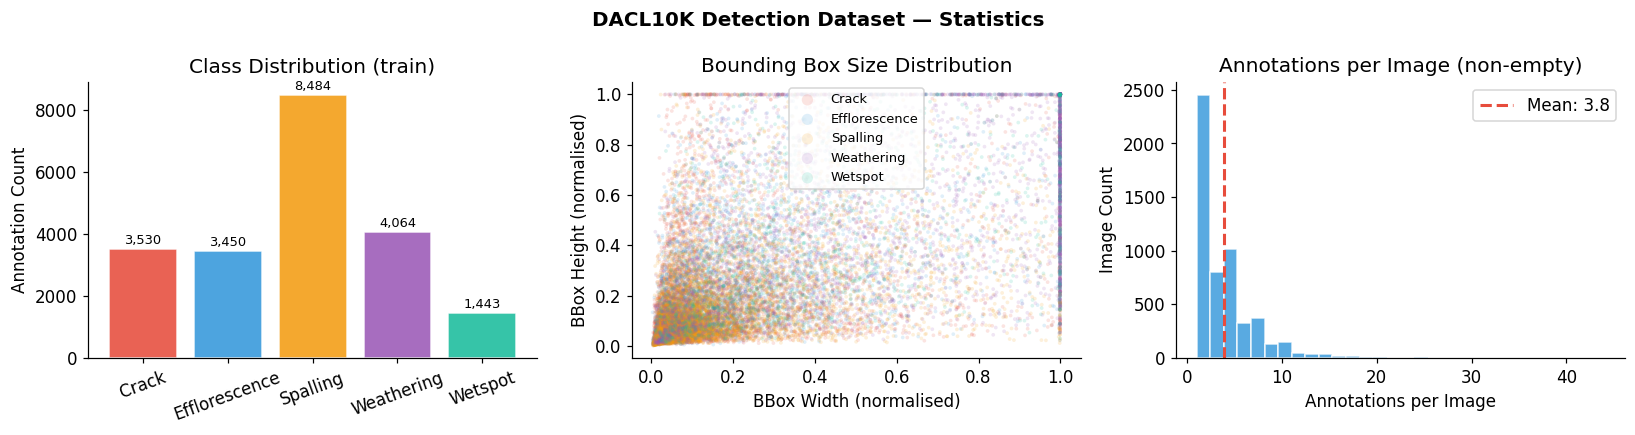

In [6]:
class_counts = Counter(all_labels)
counts = [class_counts.get(i, 0) for i in range(5)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Class distribution
bars = axes[0].bar(DETECT_CLASSES, counts, color=DETECT_COLORS, alpha=0.88, edgecolor='white')
axes[0].set_ylabel('Annotation Count')
axes[0].set_title('Class Distribution (train)')
axes[0].tick_params(axis='x', rotation=20)
for bar, cnt in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 60,
                 f'{cnt:,}', ha='center', va='bottom', fontsize=8.5)

# BBox size scatter
bw_arr  = np.array([b[0] for b in all_bboxes])
bh_arr  = np.array([b[1] for b in all_bboxes])
lbl_arr = np.array(all_labels)
for i, (cls, col) in enumerate(zip(DETECT_CLASSES, DETECT_COLORS)):
    mask = lbl_arr == i
    axes[1].scatter(bw_arr[mask], bh_arr[mask],
                    c=col, label=cls, alpha=0.15, s=6, edgecolors='none')
axes[1].set_xlabel('BBox Width (normalised)')
axes[1].set_ylabel('BBox Height (normalised)')
axes[1].set_title('Bounding Box Size Distribution')
axes[1].legend(markerscale=3, fontsize=8.5)

# Annotations per image
non_empty = [v for v in bpi_train if v > 0]
axes[2].hist(non_empty, bins=30, color='#3498db', alpha=0.82, edgecolor='white')
mean_bpi = np.mean(non_empty)
axes[2].axvline(mean_bpi, color='#e74c3c', lw=2, ls='--', label=f'Mean: {mean_bpi:.1f}')
axes[2].set_xlabel('Annotations per Image')
axes[2].set_ylabel('Image Count')
axes[2].set_title('Annotations per Image (non-empty)')
axes[2].legend()

plt.suptitle('DACL10K Detection Dataset — Statistics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_EDA / '04_detection_stats.png', bbox_inches='tight', dpi=150)
plt.show()

### Spatial Distribution of Defect Annotations

Aggregating bounding-box centres $(x_c, y_c)$ across all training images reveals **spatial bias**
in the dataset — i.e., whether certain image regions contain more annotations than others.
The density map is Gaussian-smoothed ($\sigma = 2$ grid cells) to reduce discretisation noise:

$$
H_{\text{smooth}}(i, j) = \sum_{k,l} H(k, l)\; G(i-k, j-l;\, \sigma)
$$

A uniform heatmap indicates no positional bias; concentrated hot-spots may indicate a dataset artefact
(e.g., camera consistently pointing at lower-third of facade).

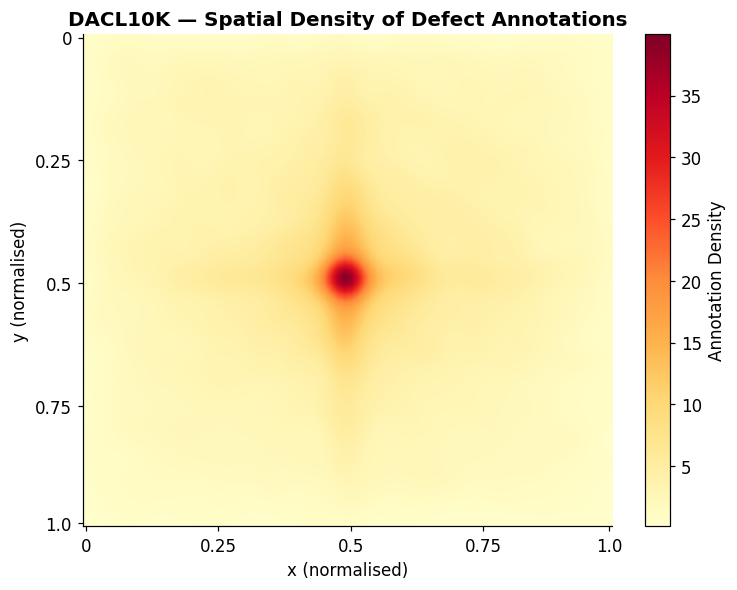

In [7]:
from scipy.ndimage import gaussian_filter

heatmap = np.zeros((80, 80), dtype=float)
for xc, yc in zip(xc_list, yc_list):
    xi = min(int(xc * 80), 79)
    yi = min(int(yc * 80), 79)
    heatmap[yi, xi] += 1

heatmap_smooth = gaussian_filter(heatmap, sigma=2)

fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(heatmap_smooth, cmap='YlOrRd', aspect='auto', interpolation='bilinear')
plt.colorbar(im, ax=ax, label='Annotation Density')
tick_pos    = [0, 20, 40, 60, 79]
tick_labels = ['0', '0.25', '0.5', '0.75', '1.0']
ax.set_xticks(tick_pos); ax.set_xticklabels(tick_labels)
ax.set_yticks(tick_pos); ax.set_yticklabels(tick_labels)
ax.set_xlabel('x (normalised)')
ax.set_ylabel('y (normalised)')
ax.set_title('DACL10K — Spatial Density of Defect Annotations',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_EDA / '05_bbox_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

### Ground-Truth Bounding Boxes on Sample Images

Images below are selected to show **co-occurring defect classes** — i.e. images annotated with at least two different
defect types. This is the dominant real-world scenario on heritage facades, where cracks are often accompanied
by efflorescence or weathering.

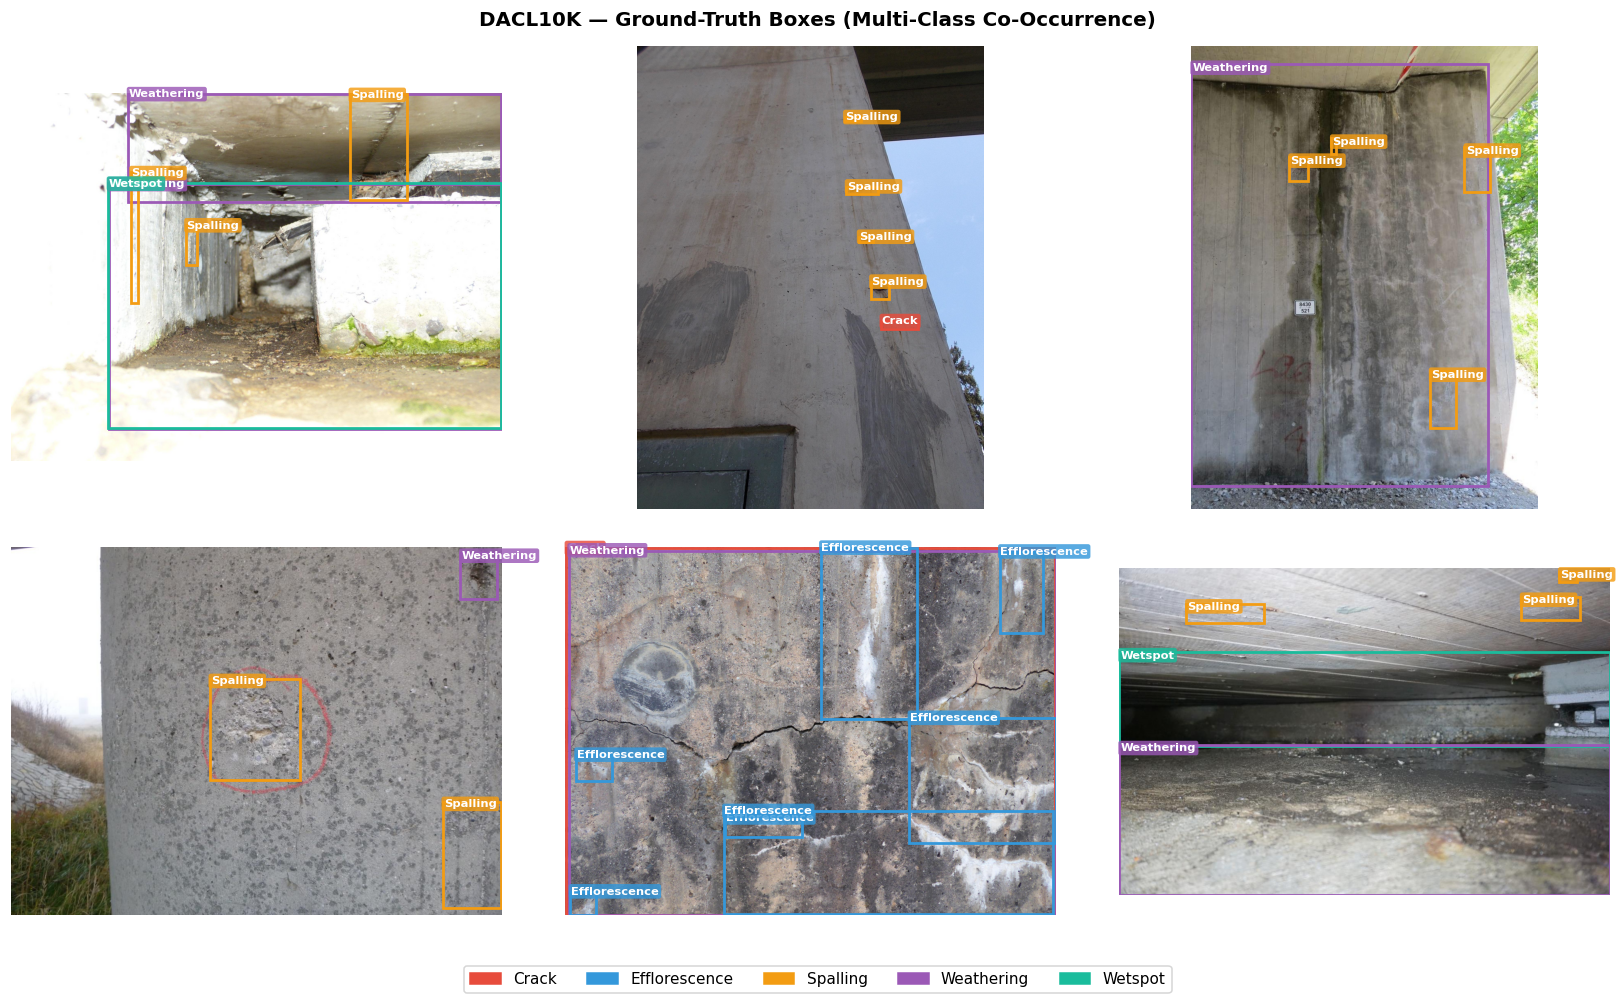

In [8]:
img_dir = Path('../data/dacl10k_yolo/images/train')
selected_stems = candidate_multi[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, stem in zip(axes, selected_stems):
    img_path = img_dir / f'{stem}.jpg'
    lbl_path = label_dir / f'{stem}.txt'
    if not img_path.exists():
        ax.axis('off')
        continue
    img = np.array(Image.open(img_path).convert('RGB'))
    h, w = img.shape[:2]
    ax.imshow(img)
    for line in lbl_path.read_text().strip().split('\n'):
        parts = line.split()
        if len(parts) < 5:
            continue
        cid = int(parts[0])
        xc, yc, bw, bh = (float(parts[1]), float(parts[2]),
                           float(parts[3]), float(parts[4]))
        x1 = (xc - bw / 2) * w
        y1 = (yc - bh / 2) * h
        rect = patches.Rectangle(
            (x1, y1), bw * w, bh * h,
            linewidth=1.8, edgecolor=DETECT_COLORS[cid], facecolor='none')
        ax.add_patch(rect)
        ax.text(x1 + 3, y1 + 14, DETECT_CLASSES[cid],
                color='white', fontsize=7.5, fontweight='bold',
                bbox=dict(facecolor=DETECT_COLORS[cid], alpha=0.82,
                          pad=1.5, edgecolor='none', boxstyle='round,pad=0.2'))
    ax.axis('off')

fig.legend(
    handles=[Patch(color=c, label=n) for c, n in zip(DETECT_COLORS, DETECT_CLASSES)],
    loc='lower center', ncol=5, fontsize=10, bbox_to_anchor=(0.5, -0.02))
plt.suptitle('DACL10K — Ground-Truth Boxes (Multi-Class Co-Occurrence)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_EDA / '06_detection_samples.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 4. Segmentation Data

Semantic segmentation assigns a binary label to **every pixel**: crack (1) or background (0).
Performance is measured with the **Intersection over Union (Jaccard Index)**:

$$
\text{IoU} = \frac{|\hat{M} \cap M_{gt}|}{|\hat{M} \cup M_{gt}|} = \frac{TP}{TP + FP + FN}
$$

where $\hat{M}$ is the predicted binary mask and $M_{gt}$ is the ground-truth mask.

To quantify how **challenging** each image is, we compute the **crack pixel density**:

$$
\rho = \frac{1}{H \cdot W} \sum_{i=1}^{H}\sum_{j=1}^{W} \mathbf{1}\bigl[M_{gt}(i,j) = 1\bigr]
$$

Low $\rho$ (< 1%) indicates sparse, hairline cracks — the hardest case for segmentation models.
Ground-truth masks use value **255** for crack pixels and **0** for background (thresholded at 127 for loading).

CrackForest pairs: 118
Masonry pairs:     240
OmniCrack30K pairs: 22,158  (using 1 sample)


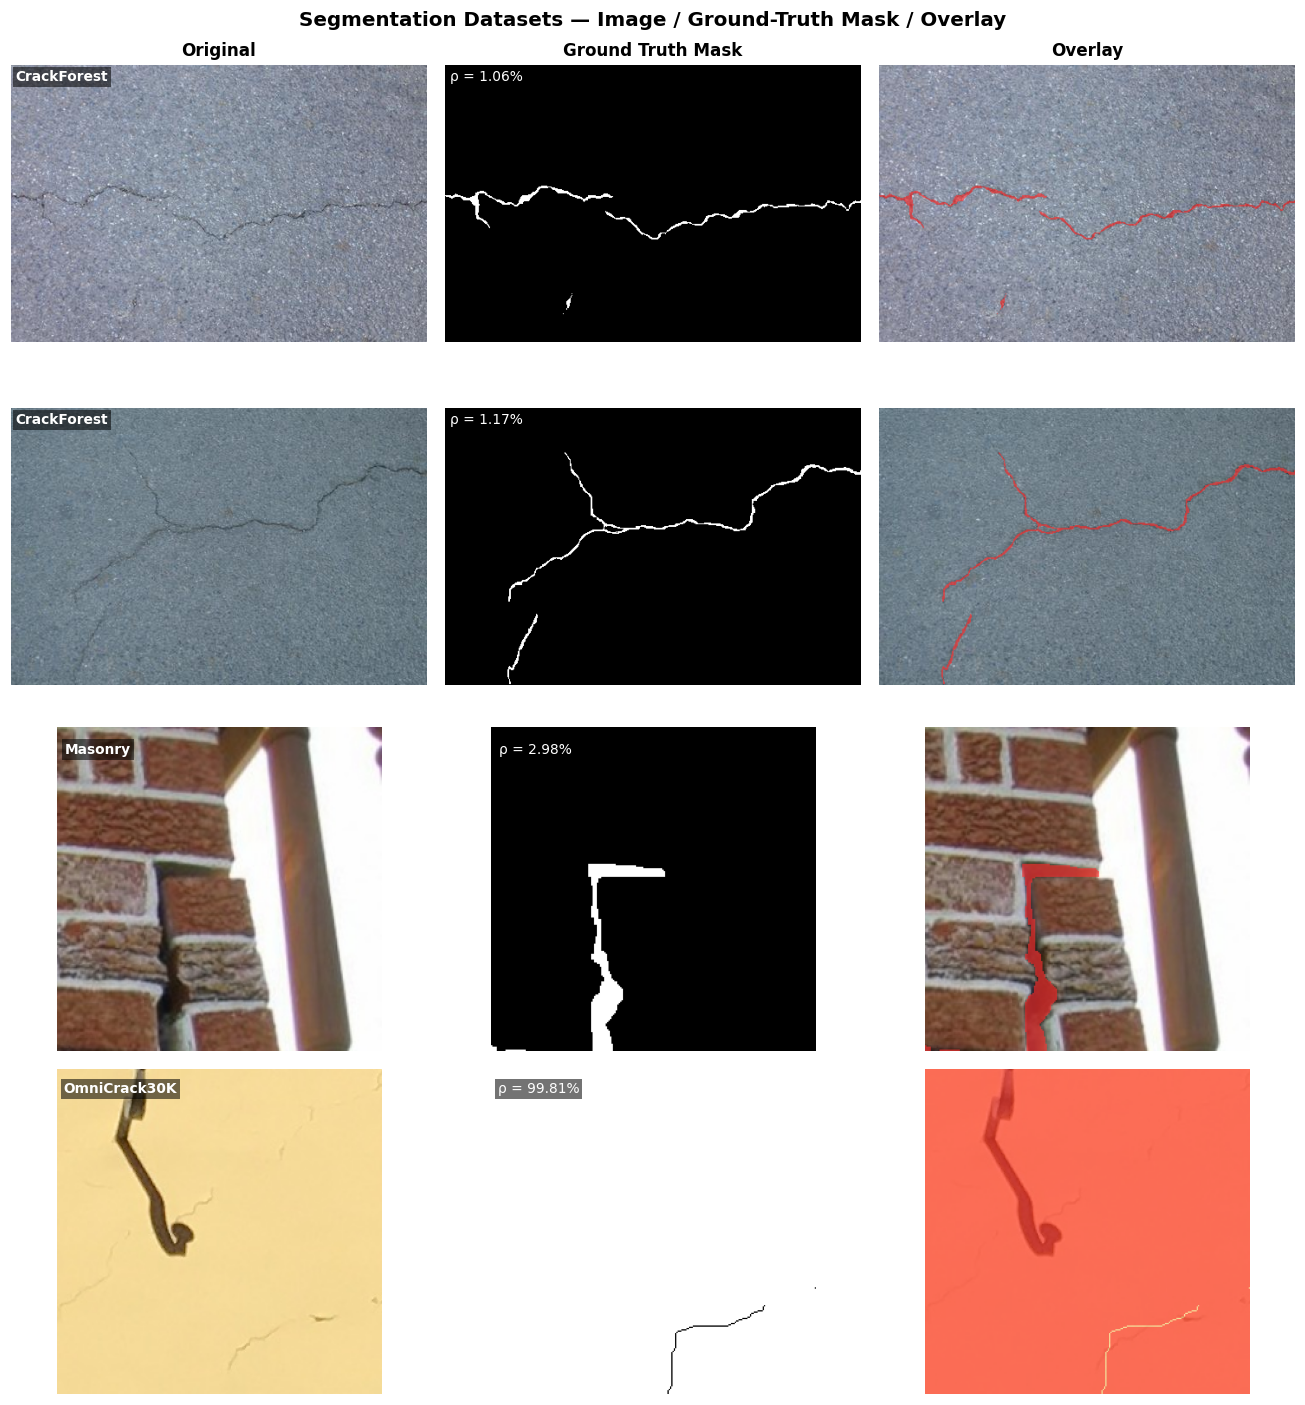

In [9]:
def get_paired_paths(img_dir, mask_dir):
    exts = {'.jpg', '.jpeg', '.png', '.bmp'}
    imgs  = {p.stem: p for p in Path(img_dir).iterdir()  if p.suffix.lower() in exts}
    masks = {p.stem: p for p in Path(mask_dir).iterdir() if p.suffix.lower() in exts}
    common = sorted(set(imgs) & set(masks))
    return [(str(imgs[s]), str(masks[s])) for s in common]

cf_pairs = get_paired_paths('../data/crackforest/images', '../data/crackforest/masks')
ms_pairs = get_paired_paths('../data/masonry/images',    '../data/masonry/masks')
oc_pairs = get_paired_paths('../data/omnicrack30k/images/training',
                            '../data/omnicrack30k/annotations/training')
print(f'CrackForest pairs: {len(cf_pairs)}')
print(f'Masonry pairs:     {len(ms_pairs)}')
print(f'OmniCrack30K pairs: {len(oc_pairs):,}  (using 1 sample)')

random.shuffle(cf_pairs)
random.shuffle(ms_pairs)
random.shuffle(oc_pairs)
selected_pairs = cf_pairs[:2] + ms_pairs[:1] + oc_pairs[:1]  # 2 CF + 1 MS + 1 OC
row_labels = ['CrackForest', 'CrackForest', 'Masonry', 'OmniCrack30K']

fig, axes = plt.subplots(4, 3, figsize=(12, 13))
for col, title in enumerate(['Original', 'Ground Truth Mask', 'Overlay']):
    axes[0, col].set_title(title, fontsize=11, fontweight='bold', pad=6)

for row, (img_path, mask_path) in enumerate(selected_pairs):
    img      = np.array(Image.open(img_path).convert('RGB'))
    raw_mask = Image.open(mask_path)
    mask     = np.array(raw_mask) if np.array(raw_mask).dtype == bool else np.array(raw_mask.convert('L'))
    mask_bin = mask.astype(np.uint8) if mask.dtype == bool else (mask > 127).astype(np.uint8)

    overlay = img.copy().astype(float)
    overlay[mask_bin == 1] = (overlay[mask_bin == 1] * 0.35
                               + np.array([255, 50, 50]) * 0.65)
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)

    pct = mask_bin.sum() / mask_bin.size * 100

    axes[row, 0].imshow(img)
    axes[row, 0].axis('off')
    axes[row, 0].text(5, 18, row_labels[row], color='white', fontsize=9, fontweight='bold',
                      bbox=dict(facecolor='black', alpha=0.55, pad=2, edgecolor='none'))

    axes[row, 1].imshow(mask, cmap='gray')
    axes[row, 1].axis('off')
    axes[row, 1].text(5, 18, f'\u03c1 = {pct:.2f}%', color='white', fontsize=9,
                      bbox=dict(facecolor='black', alpha=0.55, pad=2, edgecolor='none'))

    axes[row, 2].imshow(overlay)
    axes[row, 2].axis('off')

plt.suptitle('Segmentation Datasets — Image / Ground-Truth Mask / Overlay',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_EDA / '07_segmentation_gallery.png', bbox_inches='tight', dpi=150)
plt.show()

### Crack Density Distribution

The histogram below shows $\rho$ (crack pixel %) across all images in each dataset.
A right-skewed distribution (most images have very low $\rho$) is typical of crack datasets
and is the primary reason **IoU — not pixel accuracy — is the standard metric**: a model predicting
all pixels as background can achieve > 98% accuracy yet IoU = 0.

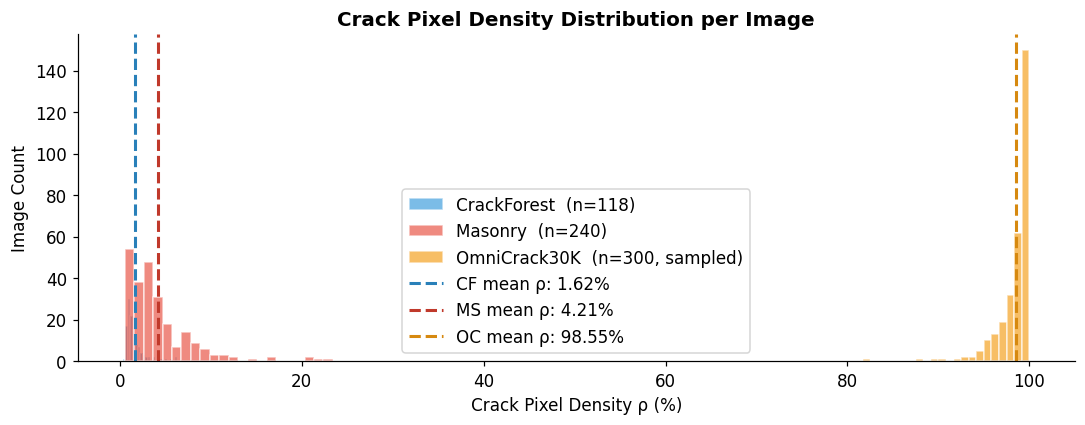

CrackForest  — median ρ: 1.31%,  max: 6.33%
Masonry      — median ρ: 3.15%,  max: 23.43%
OmniCrack30K — median ρ: 99.20%,  max: 100.00% (sample)


In [10]:
def crack_densities(pairs):
    densities = []
    for _, mask_path in pairs:
        mask = np.array(Image.open(mask_path))
        mask_bin = mask.astype(np.uint8) if mask.dtype == bool else (mask > 127).astype(np.uint8)
        densities.append(mask_bin.sum() / mask_bin.size * 100)
    return densities

d_cf = crack_densities(cf_pairs)
d_ms = crack_densities(ms_pairs)
d_oc = crack_densities(oc_pairs[:300])  # sample 300 — full set would take minutes

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(d_cf, bins=22, alpha=0.65, color='#3498db',
        label=f'CrackForest  (n={len(d_cf)})', edgecolor='white')
ax.hist(d_ms, bins=22, alpha=0.65, color='#e74c3c',
        label=f'Masonry  (n={len(d_ms)})', edgecolor='white')
ax.hist(d_oc, bins=22, alpha=0.65, color='#f39c12',
        label=f'OmniCrack30K  (n={len(d_oc)}, sampled)', edgecolor='white')
ax.axvline(np.mean(d_cf), color='#2980b9', lw=2, ls='--',
           label=f'CF mean \u03c1: {np.mean(d_cf):.2f}%')
ax.axvline(np.mean(d_ms), color='#c0392b', lw=2, ls='--',
           label=f'MS mean \u03c1: {np.mean(d_ms):.2f}%')
ax.axvline(np.mean(d_oc), color='#d68910', lw=2, ls='--',
           label=f'OC mean \u03c1: {np.mean(d_oc):.2f}%')
ax.set_xlabel('Crack Pixel Density \u03c1 (%)')
ax.set_ylabel('Image Count')
ax.set_title('Crack Pixel Density Distribution per Image',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_EDA / '08_crack_density.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'CrackForest  — median \u03c1: {np.median(d_cf):.2f}%,  max: {max(d_cf):.2f}%')
print(f'Masonry      — median \u03c1: {np.median(d_ms):.2f}%,  max: {max(d_ms):.2f}%')
print(f'OmniCrack30K — median \u03c1: {np.median(d_oc):.2f}%,  max: {max(d_oc):.2f}% (sample)')

---
## 5. Image Statistics

### 5a. Resolution Distribution

Different datasets were collected under different protocols, resulting in **heterogeneous image resolutions**.
Before training, all images are resized to a fixed resolution (224 × 224 for classification, 640 × 640 for detection).
Understanding the original resolution distribution informs whether significant downsampling occurs
(which can erase fine crack detail).

### 5b. RGB Channel Distributions

Per-channel intensity histograms reveal **domain shift** between datasets.
Heritage imagery (DACL10K, CrackForest) tends to have lower colour saturation and more uniform
grey tones compared to the general StructDamage dataset — motivating domain adaptation strategies.

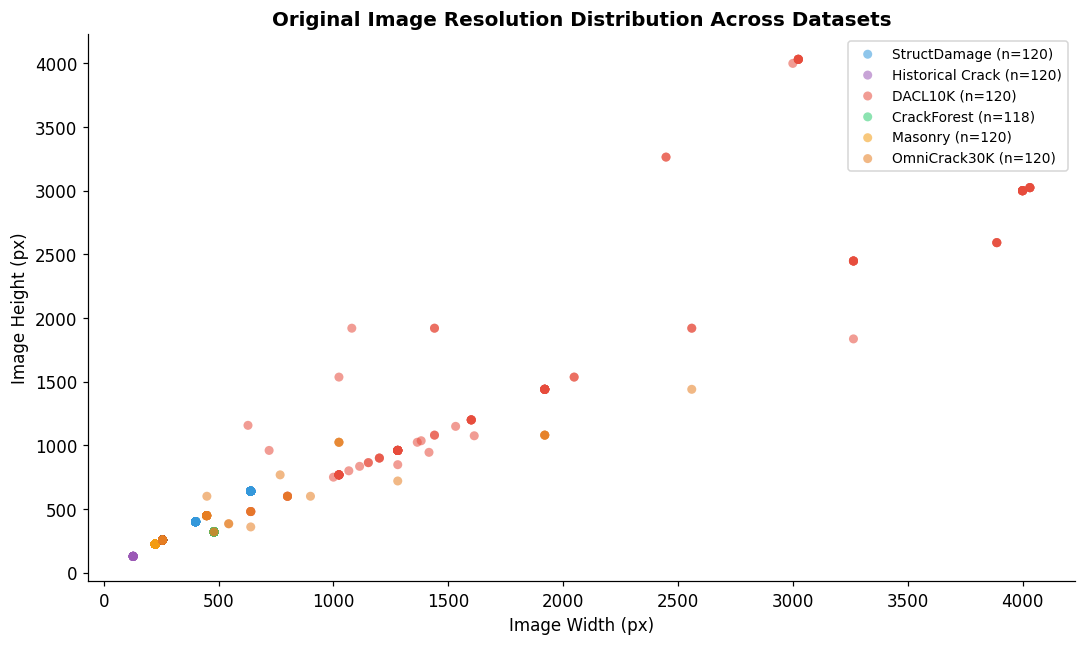

In [11]:
def sample_dims(pattern, n=120):
    paths = glob.glob(pattern)
    random.shuffle(paths)
    dims = []
    for p in paths[:n]:
        try:
            with Image.open(p) as im:
                dims.append(im.size)  # (W, H)
        except Exception:
            pass
    return dims

dim_datasets = [
    (sample_dims('../data/structdamage_classifier/train/cracked/*.jpg'), '#3498db', 'StructDamage'),
    (sample_dims('../data/historical_crack/cracked/*.jpg'),             '#9b59b6', 'Historical Crack'),
    (sample_dims('../data/dacl10k_yolo/images/train/*.jpg'),            '#e74c3c', 'DACL10K'),
    (sample_dims('../data/crackforest/images/*.jpg'),                   '#2ecc71', 'CrackForest'),
    (sample_dims('../data/masonry/images/*'),                           '#f39c12', 'Masonry'),
    (sample_dims('../data/omnicrack30k/images/training/*.png'),         '#e67e22', 'OmniCrack30K'),
]

fig, ax = plt.subplots(figsize=(10, 6))
for dims, color, label in dim_datasets:
    if not dims:
        continue
    ws = [d[0] for d in dims]
    hs = [d[1] for d in dims]
    ax.scatter(ws, hs, c=color, label=f'{label} (n={len(dims)})',
               alpha=0.55, s=35, edgecolors='none')
ax.set_xlabel('Image Width (px)')
ax.set_ylabel('Image Height (px)')
ax.set_title('Original Image Resolution Distribution Across Datasets',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUT_EDA / '09_image_dimensions.png', bbox_inches='tight', dpi=150)
plt.show()

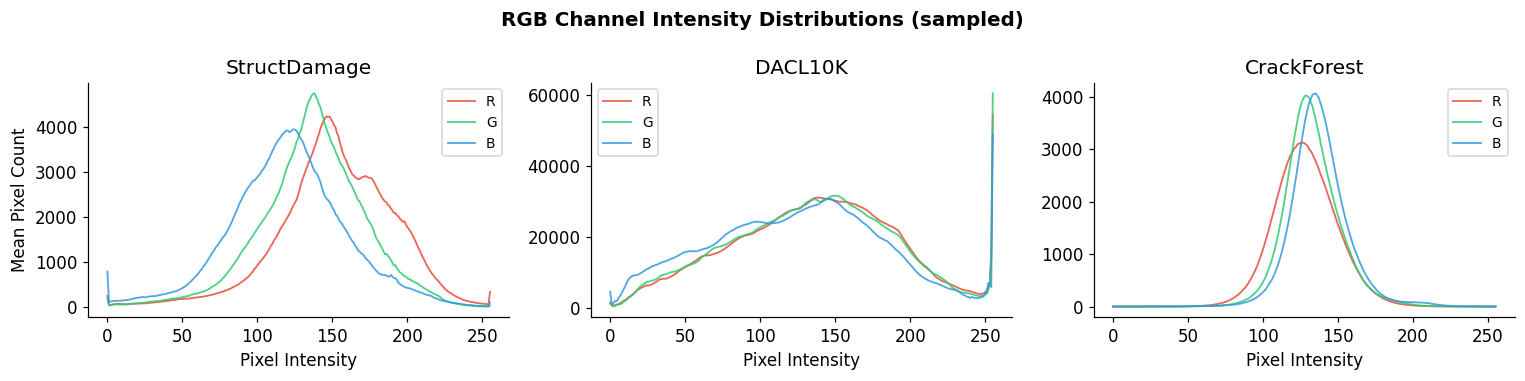

In [12]:
def mean_rgb_hist(pattern, n=80):
    paths = glob.glob(pattern)
    random.shuffle(paths)
    r_hist = np.zeros(256)
    g_hist = np.zeros(256)
    b_hist = np.zeros(256)
    count  = 0
    for p in paths[:n]:
        try:
            arr = np.array(Image.open(p).convert('RGB'))
            r_hist += np.bincount(arr[:, :, 0].ravel(), minlength=256)
            g_hist += np.bincount(arr[:, :, 1].ravel(), minlength=256)
            b_hist += np.bincount(arr[:, :, 2].ravel(), minlength=256)
            count  += 1
        except Exception:
            pass
    if count == 0:
        return None
    return r_hist / count, g_hist / count, b_hist / count

rgb_datasets = [
    (mean_rgb_hist('../data/structdamage_classifier/train/cracked/*.jpg'), 'StructDamage'),
    (mean_rgb_hist('../data/dacl10k_yolo/images/train/*.jpg'),            'DACL10K'),
    (mean_rgb_hist('../data/crackforest/images/*.jpg'),                   'CrackForest'),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=False)
ch_colors = ['#e74c3c', '#2ecc71', '#3498db']
ch_names  = ['R', 'G', 'B']

for ax, (hists, ds_name) in zip(axes, rgb_datasets):
    if hists is None:
        ax.axis('off')
        continue
    x = np.arange(256)
    for hist, color, ch in zip(hists, ch_colors, ch_names):
        ax.plot(x, hist, color=color, lw=1.2, label=ch, alpha=0.85)
    ax.set_title(ds_name)
    ax.set_xlabel('Pixel Intensity')
    ax.legend(fontsize=9)

axes[0].set_ylabel('Mean Pixel Count')
plt.suptitle('RGB Channel Intensity Distributions (sampled)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_EDA / '10_rgb_histograms.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 6. Learned Feature Space — t-SNE (EfficientNet-B4)

t-SNE (van der Maaten & Hinton, 2008) is a non-linear dimensionality reduction technique that embeds
high-dimensional feature vectors into 2D while preserving local neighbourhood structure.
It minimises the **KL divergence** between the high-dimensional joint probability distribution $P$
and the 2D Student-t distribution $Q$:

$$
\mathcal{L}_{\text{t-SNE}} = \text{KL}(P \,\|\, Q) = \sum_{i \neq j} p_{ij} \log \frac{p_{ij}}{q_{ij}}
$$

Here we project EfficientNet-B4 penultimate-layer embeddings (1792-D) of the **test set** into 2D.
Well-separated clusters indicate that the backbone has learned **discriminative crack vs. intact features**.
Colour encodes the **domain** of origin — showing whether features from different datasets cluster together
or remain domain-separated.

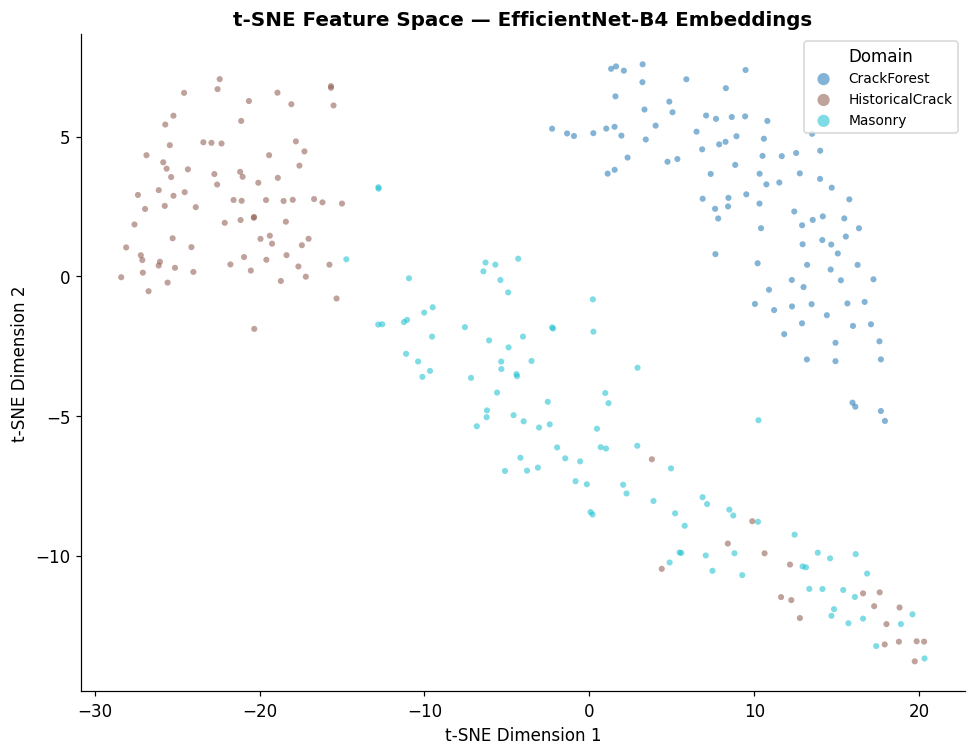

Points: 300  |  Groups: ['CrackForest', 'HistoricalCrack', 'Masonry']


In [13]:
tsne_png = Path('../outputs/tsne_efficientnet_b4.png')
tsne_csv = Path('../outputs/tsne_efficientnet_b4.csv')

if tsne_csv.exists():
    with open(tsne_csv, newline='') as f:
        reader = csv.DictReader(f)
        rows   = list(reader)

    cols       = list(rows[0].keys()) if rows else []
    lower_cols = [c.lower() for c in cols]

    # Identify x, y, and group columns
    x_key = next((c for c, lc in zip(cols, lower_cols) if lc in ('x', 'tsne_x', 'dim1', 'dim_1')), cols[0] if cols else None)
    y_key = next((c for c, lc in zip(cols, lower_cols) if lc in ('y', 'tsne_y', 'dim2', 'dim_2')), cols[1] if len(cols)>1 else None)
    g_key = next((c for c, lc in zip(cols, lower_cols)
                  if lc in ('domain', 'label', 'class', 'target', 'split')), None)

    xs = np.array([float(r[x_key]) for r in rows])
    ys = np.array([float(r[y_key]) for r in rows])

    fig, ax = plt.subplots(figsize=(9, 7))
    if g_key:
        groups = [r[g_key] for r in rows]
        unique_groups = sorted(set(groups))
        cmap = plt.cm.get_cmap('tab10', len(unique_groups))
        for i, grp in enumerate(unique_groups):
            mask = np.array([g == grp for g in groups])
            ax.scatter(xs[mask], ys[mask], c=[cmap(i)], label=grp,
                       alpha=0.55, s=16, edgecolors='none')
        ax.legend(title=g_key.title(), fontsize=9, markerscale=2)
    else:
        ax.scatter(xs, ys, alpha=0.4, s=12, color='#3498db')

    ax.set_xlabel('t-SNE Dimension 1')
    ax.set_ylabel('t-SNE Dimension 2')
    ax.set_title('t-SNE Feature Space — EfficientNet-B4 Embeddings',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUT_EDA / '11_tsne.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Points: {len(xs):,}  |  Groups: {unique_groups if g_key else "(none)"}')

elif tsne_png.exists():
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(Image.open(tsne_png))
    ax.axis('off')
    ax.set_title('t-SNE Feature Space — EfficientNet-B4 Embeddings',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUT_EDA / '11_tsne.png', bbox_inches='tight', dpi=150)
    plt.show()

else:
    print('t-SNE file not found — run 01_classification.ipynb first to generate embeddings.')

---
## Summary

| Dataset | Task | Images | Key Characteristic |
|---------|------|--------|--------------------|
| StructDamage | Classification | 14,702 | Perfectly balanced; standardised 224\u00d7224 px |
| Historical Crack | Classification | 3,896 | 1:4 class imbalance — domain-transfer evaluation |
| DACL10K | Detection | 7,910 | 5 heritage defect classes; strong long-tail distribution |
| Heritage Defect | Detection context | 408 | Single-class in-domain heritage images |
| CrackForest | Segmentation | 118 | Fine-grained hairline cracks; sparse masks (\u03c1 < 2%) |
| Masonry | Segmentation | 240 | Variable stone textures; broader crack regions |
| OmniCrack30K | Segmentation | 30,017 | Large-scale multi-source benchmark; 256×256 bool masks |

**Key findings:**
- Class imbalance in DACL10K (crack >> wetspot) motivates focal loss during detection training.
- Low crack pixel density in CrackForest explains why pixel accuracy is a misleading metric.
- Domain shift between StructDamage and Historical Crack datasets is visible in RGB histograms.
- DACL10K images are high-resolution (> 1k px); downsampling to 640\u00d7640 discards fine detail.

All figures saved to `../outputs/eda/`.